# Tohoku Tsunami — Open Elevation Data

This notebook runs the 2011 Tohoku tsunami simulation using **freely available**
global bathymetry/topography instead of the proprietary `Tohoku.pts` file.

Elevation source: **NOAA NCEI Global DEM Mosaic** (GEBCO-based), downloaded via
the ArcGIS ImageServer REST API — no registration or API key required.
- 15 arc-second (~450 m) resolution
- Land topography (SRTM-derived) + ocean bathymetry (GEBCO)
- Coverage: global

Earthquake source: KL random slip field (Karhunen–Loève expansion) via `okada_kl_subfaults`.

Gauge data from https://www.ngdc.noaa.gov/hazard/dart/2011honshu_dart.html

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import anuga
import okada_kl_subfaults as okl

%matplotlib inline
%load_ext autoreload
%autoreload 2

from matplotlib import rc
rc('animation', html='jshtml')

In [2]:
try:
    os.chdir('Tohoku')
except:
    pass
print(f'Working directory: {os.getcwd()}')

Working directory: /home/steve/Projects/Tohoku


## Download Elevation Data

Downloads a GeoTIFF covering the simulation domain from the NOAA NCEI Global DEM
Mosaic.  The file is ~19 MB and is skipped on subsequent runs if it already exists.

In [3]:
from download_elevation import download_noaa_dem

# Simulation DEM: covers the ANUGA model domain at full 15 arcsec resolution.
dem_file = 'Tohoku_dem.tif'

if not os.path.exists(dem_file):
    download_noaa_dem(dem_file, resolution_arcsec=15, padding_deg=0.5, verbose=True)
else:
    print(f'Using existing {dem_file}')

# Overview DEM: the whole Japanese archipelago plus DART 21418, used only for
# the locality map below.  Coarse (60 arcsec) since it is never interpolated
# onto the mesh -- keeps the download to ~6 MB.
japan_dem_file = 'Japan_dem.tif'
japan_dem_bounds = (127.0, 150.5, 29.5, 46.5)   # lon_min, lon_max, lat_min, lat_max

if not os.path.exists(japan_dem_file):
    download_noaa_dem(japan_dem_file, bounds=japan_dem_bounds,
                      resolution_arcsec=60, padding_deg=0.0, verbose=True)
else:
    print(f'Using existing {japan_dem_file}')


Using existing Tohoku_dem.tif
Using existing Japan_dem.tif


## Gauge Locations

In [4]:
import utm

class Gauge:
    def __init__(self, long, lat, t1=0.0, t2=1.e10):
        self.lat  = lat
        self.long = long
        self.t1   = t1
        self.t2   = t2
        east, north, zone_no, zone_letter = utm.from_latlon(lat, long, force_zone_number=54)
        self.east        = east
        self.north       = north
        self.zone_no     = zone_no
        self.zone_letter = zone_letter

gauges = {}
gauges[21418] = Gauge(148.694, 38.711)          # DART buoy used for validation
gauges[21401] = Gauge(152.583, 42.617, t1=1800.)
gauges[21413] = Gauge(152.117, 30.515, t1=1800.)
gauges[21419] = Gauge(155.736, 44.455, t1=1800.)
gauges[0]     = Gauge(141.0,   38.0)             # nearshore points
gauges[1]     = Gauge(141.0,   38.125)
gauges[2]     = Gauge(141.0,   38.25)

## Fault Parameters (KL slip field)

In [5]:
km = 1000.0

# Fault-plane centre in UTM Zone 54N (absolute coordinates).  Note this is the
# centre of the rupture plane, not the catalogue epicentre (USGS 38.322N
# 142.369E -> 619670, 4242429; JMA -> 663081, 4218877).
#
# Nominal value is x0 = 720000.0.  Shifted 40 km west to better match the
# arrival time at DART 21418: it lengthens the source-to-buoy path from 463 km
# to 502 km, delaying arrival by ~3 min.
x0 = 720000.0 - 40_000
y0 = 4200000.0

fault_parameters = dict(
    depth   = 20 * km,
    length  = 200 * km,
    width   =  50 * km,
    strike  = 195.0,
    dip     =  14.0,
    rake    =  87.0,
    slip    =  50.0, #35.0
    opening =   0.0,
    nu      =   0.25,
)

## Build ANUGA Domain

In [6]:
import project

domain = anuga.create_domain_from_regions(
    project.bounding_polygon,
    boundary_tags={'bottom': [0], 'ocean_east': [1], 'top': [2], 'onshore': [3]},
    maximum_triangle_area=project.res_whole,
    interior_regions=project.interior_regions,
    use_cache=False,
    verbose=False,
)

domain.set_epsg(32654)  # WGS 84 / UTM zone 54N
domain.set_collect_max_quantities()
domain.set_omp_num_threads(12)   # OpenMP is process-wide, not per-domain

xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner

print(f'Triangles : {len(domain)}')
print(f'Extent    : {domain.get_extent()}')
print(f'Geo ref   : {domain.geo_reference}')

Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 15000000                 88753.41           5916
Interior 3600000                  30241.19           8400
Interior 60000                    11288.13           188135
Bounding 15000000                 371317.27          24754
Estimated total number of triangles: 324581
Number of triangles: 324581
output directory: /home/steve/Projects/Tohoku/_output_Caltech
source directory: /home/steve/Projects/Tohoku/sources/Caltech.pts
Note: This is generally about 20% less than the final amount


Setting omp_num_threads to 12
Triangles : 354946
Extent    : (np.float64(0.0), np.float64(880000.0), np.float64(0.0), np.float64(570000.0))
Geo ref   : (zone=54, easting=420000.000000, northing=3950000.000000, hemisphere=northern, epsg=32654)


## Set Elevation from Downloaded GeoTIFF

ANUGA reads the tif directly via `tif2point_values`, which reprojects the domain
centroid coordinates (UTM Zone 54N) to EPSG:4326 and looks up bilinearly
interpolated values from the raster.

In [7]:
domain.set_quantity('elevation', filename=dem_file, location='centroids', verbose=True)

domain.set_name('tohoku_open_dem')

tide = 0.0
domain.set_quantity('stage', tide)

# Ensure stage >= elevation on land (no water below ground)
Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values
Stage[:] = np.maximum(Elevation, Stage)

print(f'Elevation range: {Elevation.min():.1f} m to {Elevation.max():.1f} m')

Applying fitted data to quantity
Elevation range: -8012.1 m to 1831.9 m


## Locality Map

The whole Japanese archipelago, showing the Okada fault centre, DART buoy 21418,
the ANUGA model domain, and the red box marking the Tohoku coastal region used
for the inundation close-up further down.


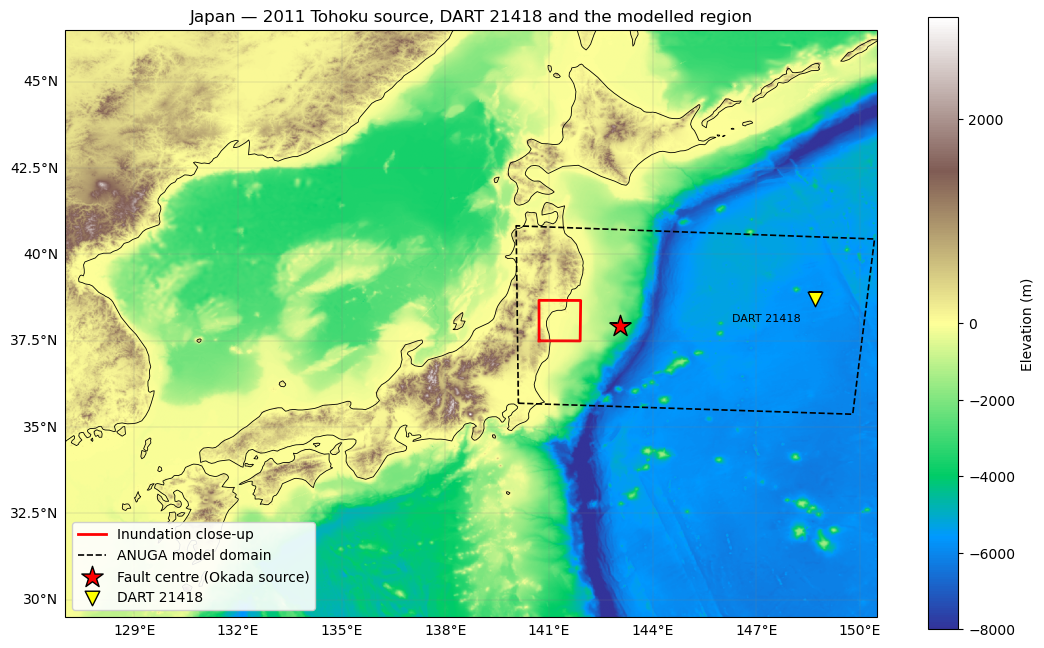

In [8]:
import rasterio
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm

# Tohoku coastal region shown in the inundation close-up (UTM Zone 54N metres).
# Defined here so the box drawn on this map and the close-up extent cannot drift.
closeup_extent = [475_000, 580_000, 4_150_000, 4_280_000]


def utm_box(extent, n=50):
    """Densified outline of a UTM rectangle, so it projects correctly."""
    xmin, xmax, ymin, ymax = extent
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    x = np.concatenate([xs, np.full(n, xmax), xs[::-1], np.full(n, xmin)])
    y = np.concatenate([np.full(n, ymin), ys, np.full(n, ymax), ys[::-1]])
    return np.append(x, x[0]), np.append(y, y[0])


def add_scalebar(ax, length_km=25, location=(0.07, 0.06), zone=54):
    """Draw a bar of known ground length on a UTM axes (exact: axes are metres)."""
    import matplotlib.patheffects as pe

    xmin, xmax, ymin, ymax = ax.get_extent(crs=ccrs.UTM(zone=zone))
    x = xmin + location[0] * (xmax - xmin)
    y = ymin + location[1] * (ymax - ymin)
    bar = length_km * 1000.0
    stroke = [pe.withStroke(linewidth=3.5, foreground='w')]

    ax.plot([x, x + bar], [y, y], color='k', lw=2.5, solid_capstyle='butt',
            transform=ccrs.UTM(zone=zone), zorder=6, path_effects=stroke)
    ax.text(x + bar / 2, y + 0.018 * (ymax - ymin), f'{length_km} km',
            ha='center', va='bottom', fontsize=9, transform=ccrs.UTM(zone=zone),
            zorder=6, path_effects=stroke)


with rasterio.open(japan_dem_file) as src:
    japan_z = src.read(1)
    b = src.bounds
japan_extent = [b.left, b.right, b.bottom, b.top]

fig, ax = plt.subplots(figsize=(11, 7.5), subplot_kw={'projection': ccrs.PlateCarree()})

img = ax.imshow(japan_z, extent=japan_extent, origin='upper',
                transform=ccrs.PlateCarree(), cmap='terrain',
                norm=TwoSlopeNorm(vcenter=0., vmin=-8000., vmax=3000.))
ax.set_extent(japan_extent, crs=ccrs.PlateCarree())

# Tohoku close-up region
bx, by = utm_box(closeup_extent)
ax.plot(bx, by, transform=ccrs.UTM(zone=54), color='red', lw=2,
        label='Inundation close-up')

# ANUGA model domain
poly = np.array(project.bounding_polygon)
ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]),
        transform=ccrs.UTM(zone=54), color='k', lw=1.2, ls='--',
        label='ANUGA model domain')

ax.scatter(x0, y0, marker='*', color='red', edgecolor='k', s=260, zorder=5,
           transform=ccrs.UTM(zone=54), label='Fault centre (Okada source)')
ax.scatter(gauges[21418].long, gauges[21418].lat, marker='v', color='yellow',
           edgecolor='k', s=110, zorder=5, transform=ccrs.PlateCarree(),
           label='DART 21418')
ax.annotate('DART 21418', xy=(gauges[21418].long, gauges[21418].lat),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            xytext=(-10, -16), textcoords='offset points', fontsize=8, ha='right')

ax.coastlines(resolution='50m', lw=0.6)
gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.legend(loc='lower left', framealpha=0.9)
plt.colorbar(img, ax=ax, shrink=0.85, label='Elevation (m)')
plt.title('Japan \u2014 2011 Tohoku source, DART 21418 and the modelled region')
plt.tight_layout()


## View Bathymetry / Topography on the Mesh

Check that the downloaded DEM has interpolated sensibly onto the model mesh.


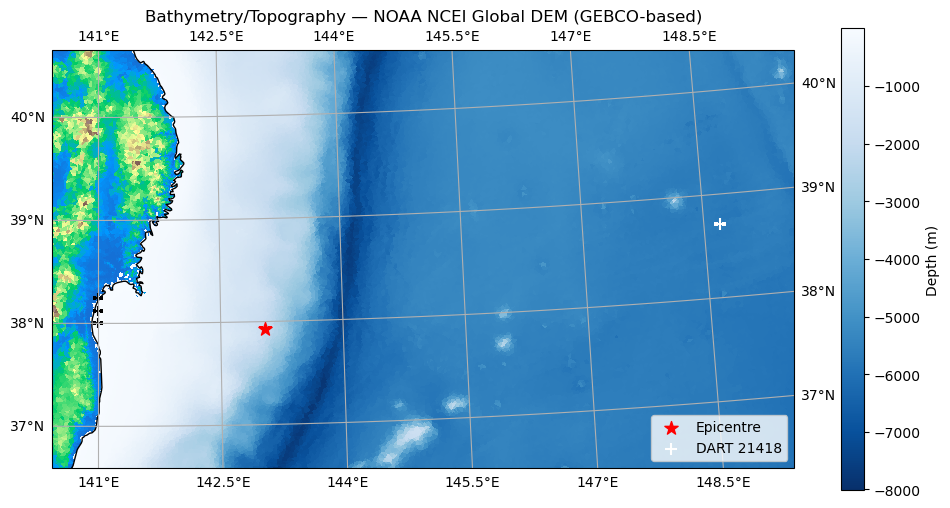

In [9]:
import cartopy.crs as ccrs

dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

md = 0.01  # wet/dry threshold

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

ax.set_extent([450_000, 1_400_000, 4_050_000, 4_500_000], crs=ccrs.UTM(zone=54))
#ax.set_extent([100_000, 1_400_000, 3_900_000, 5_200_000], crs=ccrs.UTM(zone=54))

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='Blues_r')
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='+', color='k', s=60,
               transform=ccrs.UTM(zone=54))

ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Depth (m)')
plt.title('Bathymetry/Topography — NOAA NCEI Global DEM (GEBCO-based)')
plt.tight_layout()

## Apply Earthquake Deformation

Generate a KL realisation of the slip field and compute the resulting
Okada surface deformation.  Re-run this cell to draw a new sample.

In [10]:
x = domain.centroid_coordinates[:, 0]
y = domain.centroid_coordinates[:, 1]

uE, uN, uZ, slips = okl.kl_deformation(
    x, y,
    xoff=x0 - xll,
    yoff=y0 - yll,
    E_subfault=10,
    N_subfault=10,
    sample='sobol',
    iseed=1234,
    **fault_parameters,
)

Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values

Elevation[:] += uZ
Stage[:]     += uZ

print(f'uZ range   : {uZ.min():.2f} m to {uZ.max():.2f} m')
print(f'Stage range: {Stage.min():.2f} m to {Stage.max():.2f} m')

uZ range   : -8.14 m to 21.08 m
Stage range: -8.14 m to 1831.94 m


## Initial Stage After Deformation

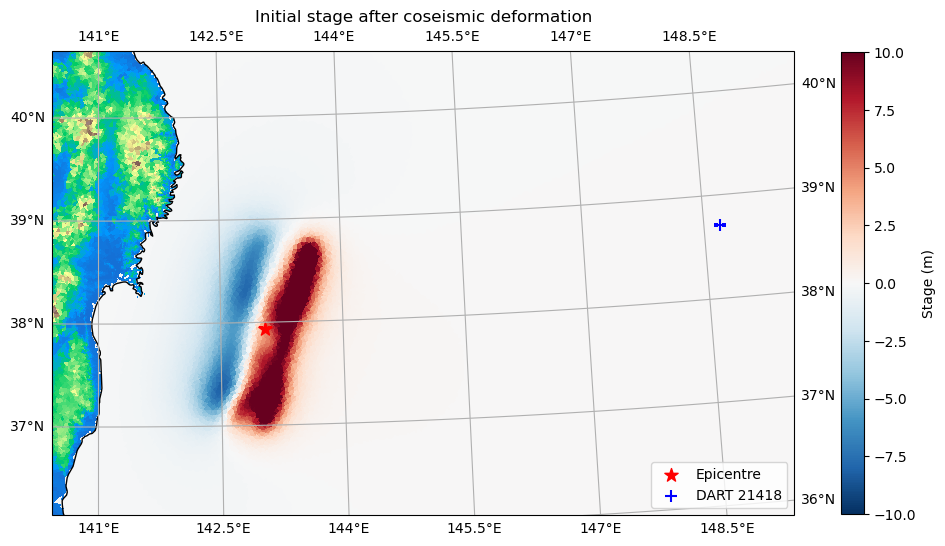

In [11]:
dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.stage, cmap='RdBu_r', vmin=-10, vmax=10)
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='b', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')

#ax.set_extent([450000, 1000000, 4050000, 4500000], crs=ccrs.UTM(zone=54))
ax.set_extent([450_000, 1_400_000, 4_000_000, 4_500_000], crs=ccrs.UTM(zone=54))
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Stage (m)')
plt.title('Initial stage after coseismic deformation')
plt.tight_layout()

## Boundary Conditions and Evolve

In [12]:
Br = anuga.Reflective_boundary(domain)
Bf = anuga.Flather_external_stage_zero_velocity_boundary(domain, lambda t: tide)

domain.set_boundary({
    'onshore':    Br,
    'bottom':     Bf,
    'ocean_east': Bf,
    'top':        Bf,
})

In [13]:
#from anuga.operators.collect_max_quantities_operator import Collect_max_quantities_operator

#max_min_collector = Collect_max_quantities_operator(domain)
max_collector = domain.max_quantities_operator

In [14]:
import time

min_  = 60.
hour_ = 3600.

tid_21418 = domain.get_triangle_containing_point([gauges[21418].east, gauges[21418].north])
tid = {k: domain.get_triangle_containing_point([gauges[k].east, gauges[k].north])
       for k in [0, 1, 2]}

gauge_time  = []
stage_21418 = []
stage_coast = {k: [] for k in [0, 1, 2]}
speed_21418 = []
speed_coast = {k: [] for k in [0, 1, 2]}
speed_depth_21418 = []
speed_depth_coast =  {k: [] for k in [0, 1, 2]}

dplotter = anuga.Domain_plotter(domain, absolute=True)

t0 = time.time()

for t in domain.evolve(yieldstep=2 * min_, finaltime=4.0 * hour_):
    gauge_time.append(t)
    stage_21418.append(dplotter.stage[tid_21418])
    for k in [0, 1, 2]:
        stage_coast[k].append(dplotter.stage[tid[k]])
        
    speed_21418.append(dplotter.speed[tid_21418])
    for k in [0, 1, 2]:
        speed_coast[k].append(dplotter.speed[tid[k]])
        
    speed_depth_21418.append(dplotter.speed_depth[tid_21418])
    for k in [0, 1, 2]:
        speed_depth_coast[k].append(dplotter.speed_depth[tid[k]])
    domain.print_timestepping_statistics()

print(f'\nSimulation took {time.time() - t0:.1f} s')

Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=997MB


Time = 120.0000 (sec), delta t in [0.66540294, 0.66546713] (s), steps=181 (2s), elapsed (2s), eta (5m:38s), mem=1002MB


Time = 240.0000 (sec), delta t in [0.66533527, 0.66540282] (s), steps=181 (2s), elapsed (5s), eta (5m:12s), mem=1005MB


Time = 360.0000 (sec), delta t in [0.66526495, 0.66533513] (s), steps=181 (2s), elapsed (7s), eta (5m), mem=1005MB


Time = 480.0000 (sec), delta t in [0.66516130, 0.66526478] (s), steps=181 (2s), elapsed (10s), eta (4m:56s), mem=1005MB


...

Time = 14040.0000 (sec), delta t in [0.66518739, 0.66525929] (s), steps=181 (2s), elapsed (4m:51s), eta (7s), mem=1006MB


Time = 14160.0000 (sec), delta t in [0.66525951, 0.66532556] (s), steps=181 (2s), elapsed (4m:53s), eta (4s), mem=1006MB


Time = 14280.0000 (sec), delta t in [0.66511125, 0.66530187] (s), steps=181 (2s), elapsed (4m:56s), eta (2s), mem=1006MB


Time = 14400.0000 (sec), delta t in [0.66489939, 0.66511079] (s), steps=181 (2s), elapsed (4m:58s), eta (0s), mem=1006MB



Simulation took 298.6 s


## Maximum Stage

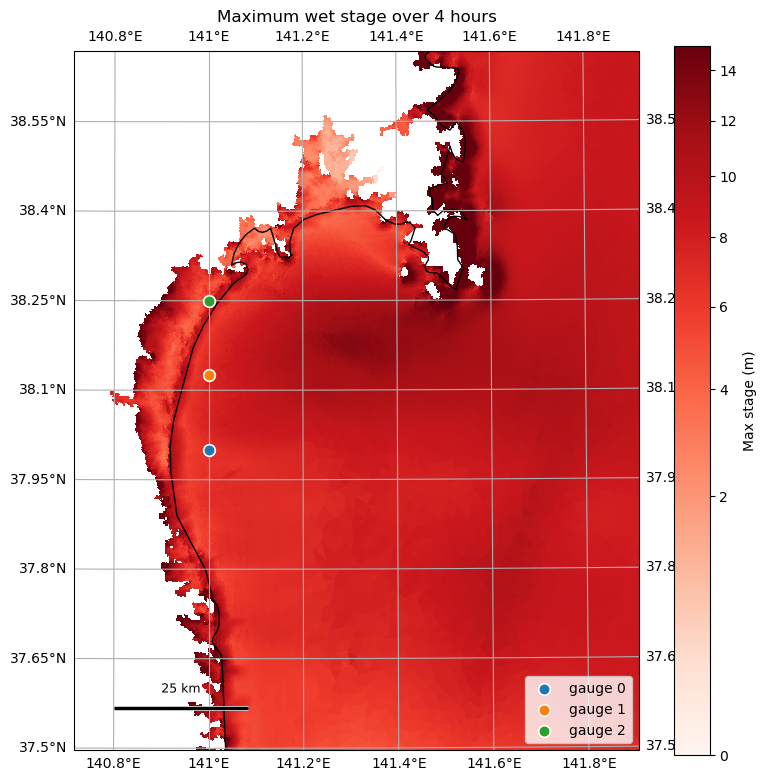

In [15]:
from matplotlib.colors import PowerNorm

max_depth = max_collector.max_depth
max_stage = max_collector.max_stage
wet_max_stage = np.where(max_depth >= 0.01, max_stage, np.nan)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

# Square-root norm: keeps the ~20 m runup peaks unsaturated while retaining
# contrast in the 2-8 m offshore range.
img = ax.tripcolor(dplotter.triang, facecolors=wet_max_stage,
                   cmap='Reds', norm=PowerNorm(gamma=0.5, vmin=0, vmax=15))

#ax.scatter(x0, y0, marker='*', color='b', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
#ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
#           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='o', s=70,
               edgecolor='w', linewidth=1.2, zorder=5,
               transform=ccrs.UTM(zone=54), label=f'gauge {k}')

ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))   # red box on the locality map
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
add_scalebar(ax, length_km=25)
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=1.0, label='Max stage (m)')
plt.title('Maximum wet stage over 4 hours')
plt.tight_layout()

## Stage Snapshots over the Close-up Region

Actual stage at selected times, read back from the `.sww` output, over the same
Tohoku coastal box outlined in red on the locality map.  The wave leaves the
source to the east and reaches the coast at around 16 minutes.


Text(0.5, 0.91, 'Stage over the Tohoku coast')

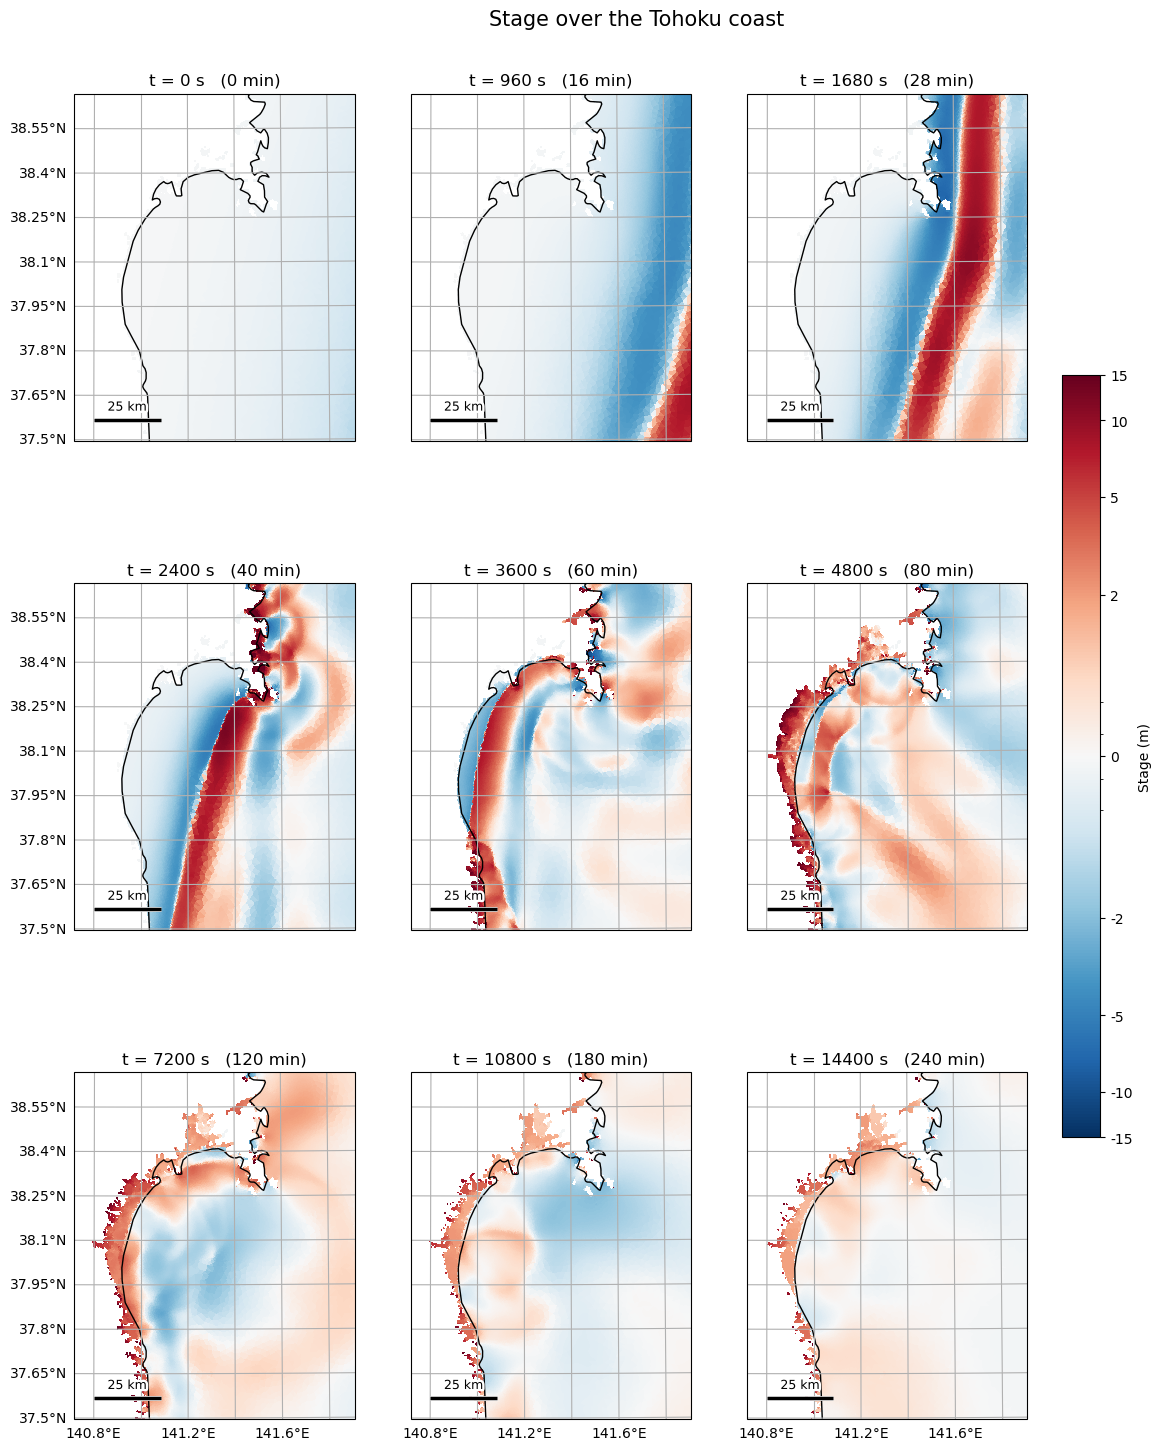

In [16]:
from matplotlib.colors import AsinhNorm

# Initial deformation, first arrival (960 s), then run-up, inundation and the
# long decay out to the end of the run at 4 hours.
snapshot_times = [0., 960., 1680., 2400., 3600., 4800., 7200., 10800., 14400.]

sww_file = domain.get_name() + '.sww'
sp = anuga.SWW_plotter(sww_file, absolute=True)
triang = sp.triang

md = 0.01                                        # wet/dry threshold

# Same +/-15 m span and the same square-root-like stretch as the maximum-stage
# figure above, but centred on 0 so the drawdown ahead of each crest is visible.
# A given red is then the same stage in both figures.
norm = AsinhNorm(linear_width=1.0, vmin=-15, vmax=15)

ncol = 3
nrow = int(np.ceil(len(snapshot_times) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 18),
                         subplot_kw={'projection': ccrs.UTM(zone=54)})
axes = axes.ravel()

for ax, t_snap in zip(axes, snapshot_times):
    f = int(np.argmin(np.abs(sp.time - t_snap)))
    wet_stage = np.where(sp.depth[f] > md, sp.stage[f], np.nan)

    triang.set_mask(sp.depth[f] <= md)
    im = ax.tripcolor(triang, facecolors=wet_stage, cmap='RdBu_r', norm=norm)
    triang.set_mask(None)

    ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))
    ax.coastlines(resolution='10m')
    add_scalebar(ax, length_km=25)

    # Label only the outer edge of the grid, or neighbouring panels collide.
    k = list(axes).index(ax)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.left_labels = (k % ncol == 0)
    gl.bottom_labels = (k >= len(snapshot_times) - ncol)

    ax.set_title(f't = {sp.time[f]:.0f} s   ({sp.time[f] / 60:.0f} min)')

for ax in axes[len(snapshot_times):]:
    ax.set_visible(False)

# AsinhNorm brings its own tick locator, so set the ticks after the fact.
ticks = [-15, -10, -5, -2, 0, 2, 5, 10, 15]
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.55, pad=0.03, label='Stage (m)')
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])
fig.suptitle('Stage over the Tohoku coast', y=0.91, fontsize=15)


## Nearshore Gauge Time Series

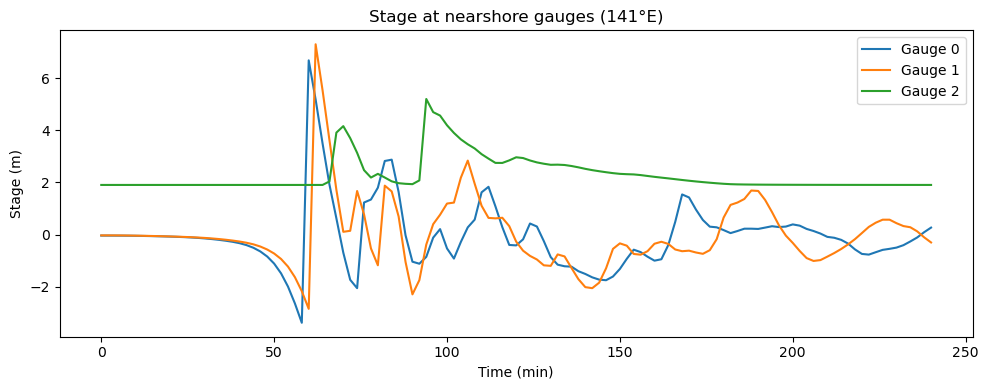

In [17]:
t = np.array(gauge_time)

fig, ax = plt.subplots(figsize=(10, 4))
# for k in [0, 1, 2]:
#     ax.plot(t / 60, stage_coast[k], label=f'Gauge {k}')
for k in [0, 1, 2]:
    ax.plot(t / 60, stage_coast[k], label=f'Gauge {k}')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('Stage at nearshore gauges (141°E)')
plt.tight_layout()

## Comparison with DART 21418 Observations

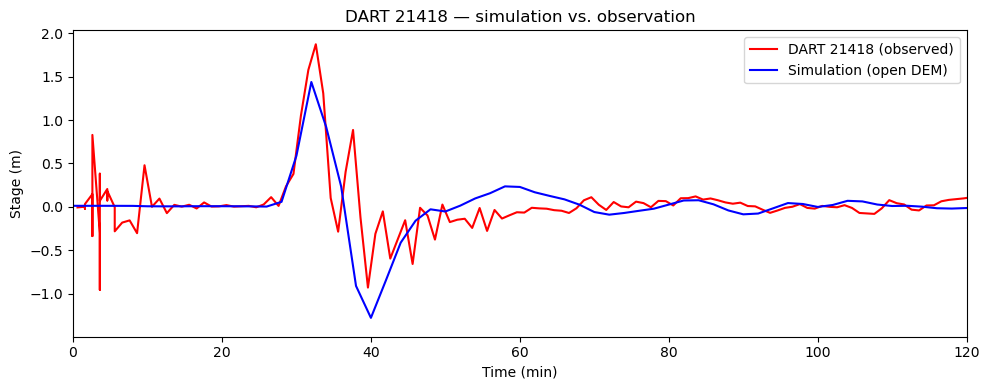

In [18]:
obs = np.loadtxt('21418_notide.txt')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(obs[:, 0] / 60, obs[:, 1], 'r', label='DART 21418 (observed)')
ax.plot(t / 60, stage_21418, 'b', label='Simulation (open DEM)')
ax.set_xlim(0, 120)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('DART 21418 — simulation vs. observation')
plt.tight_layout()